# Predicting whether a patient has Heart Disease using Machine Learning

**The goal is to build and tune a Machine Learning model capable of predicting whether or not someone has Heart Disease based on their medical attributes.**

Framework to follow:

1. Problem Definition
2. Data
3. Evaluation
4. Features
5. Modelling
6. Experimenation

## 1. Problem Definition

> Given medical attributes about a patient, can we predict whether they have Heart Disease or not?

## 2. Data

The data came from the Cleveland Database from the UCI Machine Learning Repository - https://archive.ics.uci.edu/dataset/45/heart+disease

## 3. Evaluation

> If we can reach 90% accuracy at predicting whether or not a patient has Heart Disease during this proof of concept, we'll pursure with the project.

## 4. Features

1. `age`: age in years
2. `sex`: sex (1 = male; 0 = female)
3. `cp`: chest pain type
    * Value 1: typical angina
    * Value 2: atypical angina
    * Value 3: non-anginal pain
    * Value 4: asymptomatic

4. `trestbps`: resting blood pressure (in mm Hg on admission to the hospital)
5. `chol`: serum cholestoral in mg/dl
6. `fbs`: (fasting blood sugar > 120 mg/dl)  (1 = true; 0 = false)
7. `restecg`: resting electrocardiographic results
    * Value 0: normal
    * Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
    * Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria

8. `thalach`: maximum heart rate achieved
9. `exang`: exercise induced angina (1 = yes; 0 = no)
10. `oldpeak` = ST depression induced by exercise relative to rest
11. `slope`: the slope of the peak exercise ST segment
    * Value 1: upsloping
    * Value 2: flat
    * Value 3: downsloping

12. `ca`: number of major vessels (0-3) colored by flourosopy
13. `thal`: 3 = normal; 6 = fixed defect; 7 = reversable defect
14. `target`: (1 = Heart Disease; 0 = No Heart Disease) `The predicted attribute`

### Importing the tools to use

In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn 
import seaborn as sns

# For modelling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# For Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# For Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, RocCurveDisplay, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score

%matplotlib inline

### Load Data

In [5]:
df = pd.read_csv("heart-disease.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


## EDA (Exploratory Data Analysis)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
df.shape

(303, 14)

In [11]:
# Check for missing values
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [12]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [14]:
# To see the different counts of classes
df["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

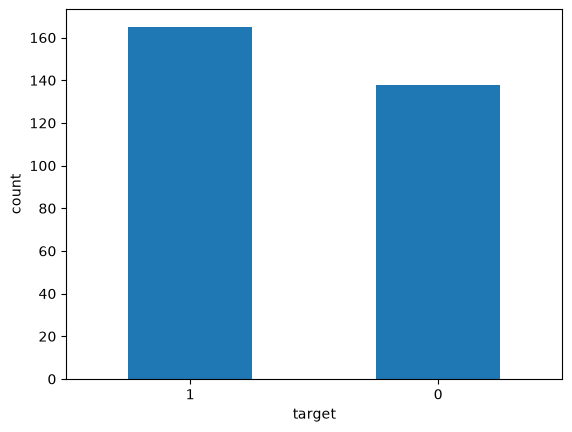

In [24]:
df["target"].value_counts().plot(kind = "bar",
                                 xlabel = "target",
                                 ylabel = "count",
                                 rot = 0);

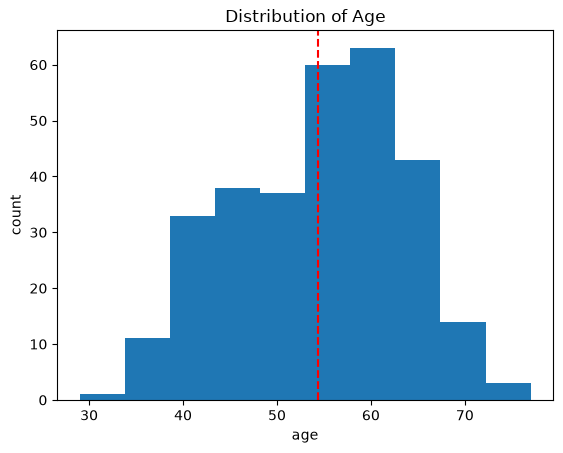

In [32]:
# Distribution of Age with mean line 
fig, ax = plt.subplots()
ax.hist(df["age"])
ax.set(xlabel = "age",
       ylabel = "count",
       title = "Distribution of Age")

ax.axvline(df["age"].mean(),
           color = "red",
           linestyle = "--");

In [33]:
df["sex"].value_counts()

sex
1    207
0     96
Name: count, dtype: int64

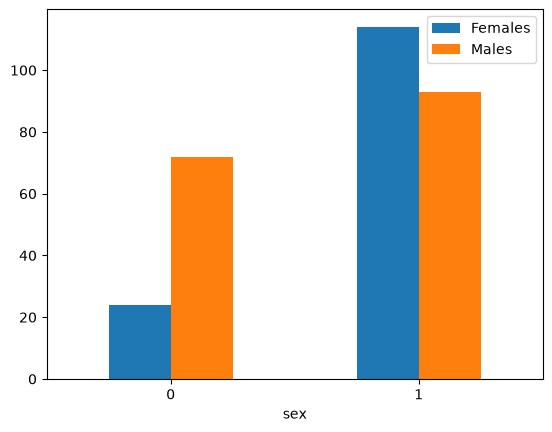

In [43]:
# Comparing 'sex' column to 'target' column using bar graph
pd.crosstab(df["sex"], df["target"]).plot(kind = "bar");

plt.xlabel = "0 = No Heart Disease, 1 = Has Heart Disease"
plt.ylabel = "Count"
plt.title = "Heart Disease Frequency for each Sex"
plt.legend(["Females", "Males"])
plt.xticks(rotation = 0);

In [44]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


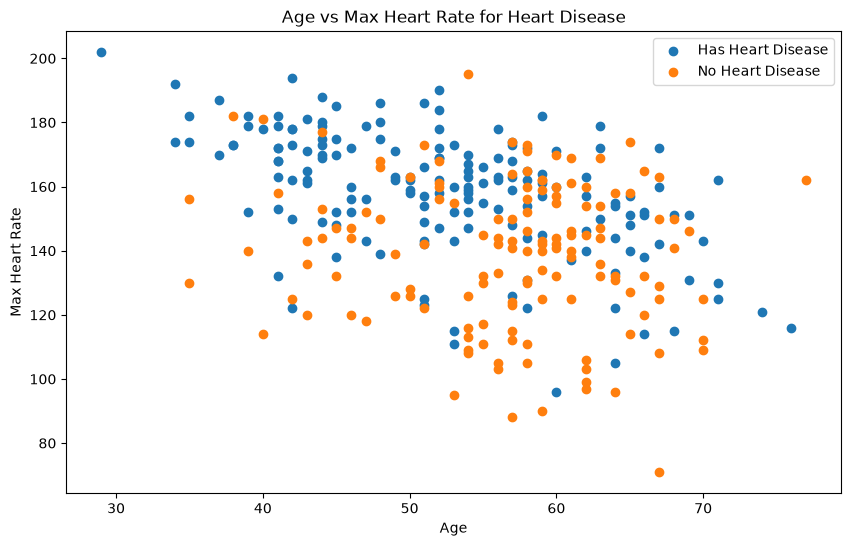

In [60]:
# Comparing Age vs Max Heart rate (thalach) for Heart Disease
fig, ax = plt.subplots(figsize = (10, 6))

# Scatter plot for Heart Disease
ax.scatter(df["age"][df["target"] == 1],
           df["thalach"][df["target"] == 1])

# Scatter plot for NO Heart Disease
ax.scatter(df["age"][df["target"] == 0],
           df["thalach"][df["target"] == 0])

# Customising the plot
ax.set(xlabel = "Age",
       ylabel = "Max Heart Rate",
       title = "Age vs Max Heart Rate for Heart Disease")
ax.legend(["Has Heart Disease", "No Heart Disease"]);

### Correlation Matrix

In [61]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


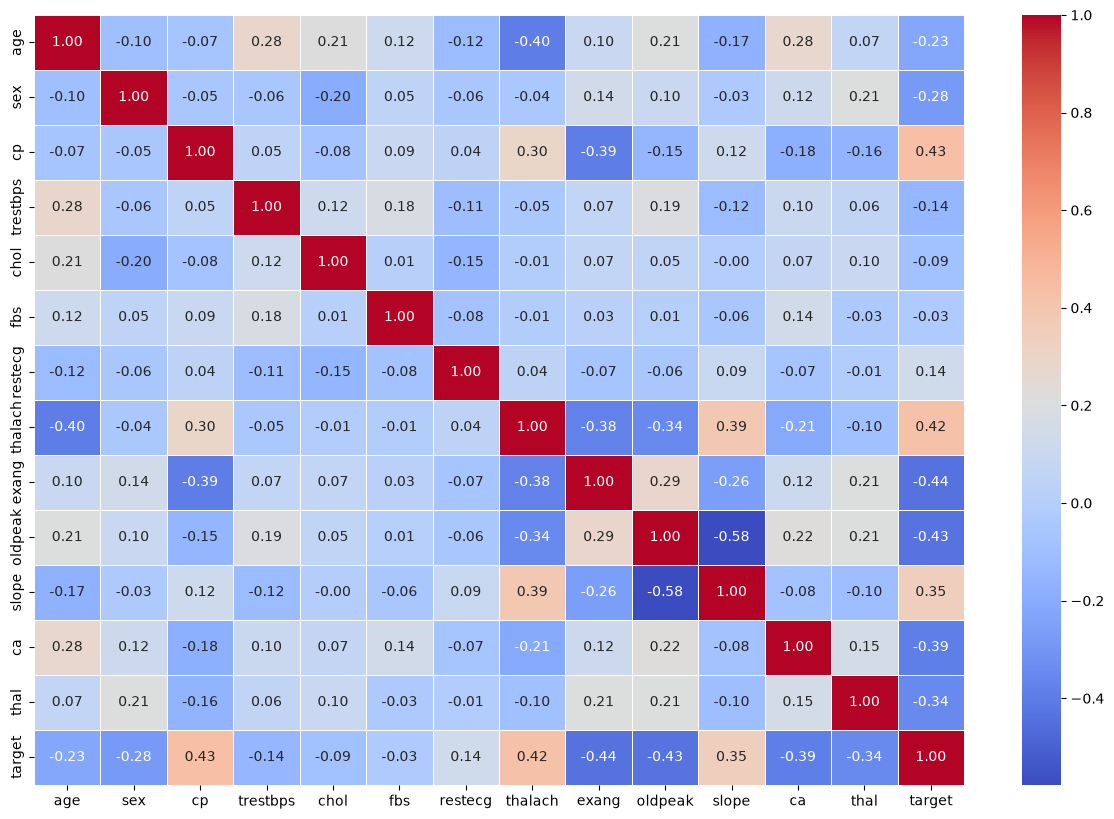

In [67]:
# Making correlation matrix with Seaborn's Heatmap
fig, ax = plt.subplots(figsize = (15, 10))
ax = sns.heatmap(df.corr(),
                 annot = True,
                 cmap = "coolwarm",
                 linewidths = 0.5,
                 fmt = ".2f");

`cp` (Chest pain type), `slope` (the slope of the peak exercise ST segment) and `thalach` (Max Heart Rate) seem to have higher positive correlation with `target` column

`exang` (exercise-induced angina) and `oldpeak` (ST depression induced by exercise relative to rest) seem to have higher negative correlation with `target` column

## 5. Modelling

In [68]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [69]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [70]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [71]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

There is no missing Data in our DataFrame and all the Data are of numeric datatype.

In [73]:
# Split Data into X (features) and y (labels)

X = df.drop("target", axis = 1)
y = df["target"]

In [74]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [75]:
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

In [76]:
X.shape, y.shape

((303, 13), (303,))

Now let's split the data into Train and Test Sets

In [77]:
# Set Random Seed
np.random.seed(42)

# Split Data into Train and Test Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [78]:
X_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
132,42,1,1,120,295,0,1,162,0,0.0,2,0,2
202,58,1,0,150,270,0,0,111,1,0.8,2,0,3
196,46,1,2,150,231,0,1,147,0,3.6,1,0,2
75,55,0,1,135,250,0,0,161,0,1.4,1,0,2
176,60,1,0,117,230,1,1,160,1,1.4,2,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,50,1,2,140,233,0,1,163,0,0.6,1,1,3
71,51,1,2,94,227,0,1,154,1,0.0,2,1,3
106,69,1,3,160,234,1,0,131,0,0.1,1,1,2
270,46,1,0,120,249,0,0,144,0,0.8,2,0,3


In [79]:
y_train

132    1
202    0
196    0
75     1
176    0
      ..
188    0
71     1
106    1
270    0
102    1
Name: target, Length: 242, dtype: int64

**Now we've got our data split into training and test sets, it's time to build a Machine Learning model.**

* We'll train it (find the patterns) on the `training set`.

* We'll test it (use the patterns found) on the `test set`.

We're going to try `3 different Machine Learning models`:

1. Logistic Regression
2. K-Nearest Neighbours Classifier
3. Random Forest Classifier

> Because we want to build 3 different models and because we want to evaluate them and do experiments to see which one is the best, we can set up a dictionary of our models and then create a function to fit and score our models.

In [104]:
# Putting the models in a dictionary
models = {"Logistic Regression": LogisticRegression(max_iter=1000),
          "KNN": KNeighborsClassifier(),
          "Random Forest Classifier": RandomForestClassifier()}

def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    This Function fits and scores the models in our models dictionary.
    models: Dictionary containing Scikit-Learn models
    X_train: training data (no labels)
    X_test: testing data (no labels)
    y_train: training labels
    y_test: testing labels
    """
    np.random.seed(42)    # Set Random Seed
    model_scores = {}     # Create empty dictionary to save scores of models
    for name, model in models.items():
        model.fit(X_train, y_train)
        model_scores[name] = model.score(X_test, y_test)
    return model_scores

In [105]:
model_scores = fit_and_score(models, X_train, X_test, y_train, y_test)
model_scores

{'Logistic Regression': 0.8852459016393442,
 'KNN': 0.6885245901639344,
 'Random Forest Classifier': 0.8360655737704918}

### Model Comparison

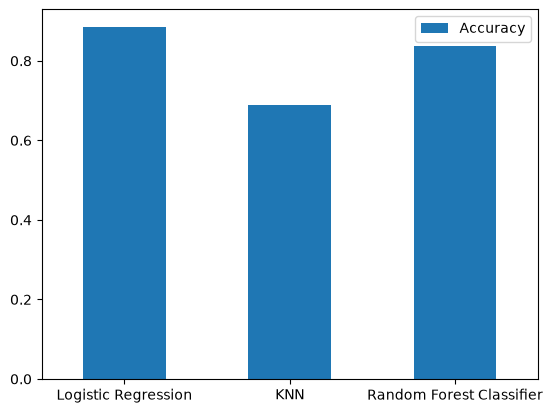

In [95]:
model_compare = pd.DataFrame(model_scores, index = ["Accuracy"])
model_compare.T.plot(kind = "bar", rot = 0);

We've got a baseline model - `Logistic Regression` with an Accuracy score of `0.8852459016393442`

### Hyperparameter Tuning with RandomizedSearchCV

In [106]:
# Create a Hyperparameter grid for Logistic Regression

log_reg_grid = {"C": np.logspace(-4, 4, 50),
                "solver": ["liblinear", "saga"]}

In [108]:
%%time
# Tune LogisticRegression model
# Set Random Seed
np.random.seed(42)
# Set random hyperparameter search for LogisticRegression
rs_log_reg = RandomizedSearchCV(LogisticRegression(),
                                param_distributions = log_reg_grid,
                                cv = 5,
                                n_iter = 100,
                                verbose = True,
                                n_jobs = -1)

# Fit random hyperparameter search model for LogisticRegression
rs_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
CPU times: total: 4.36 s
Wall time: 16.6 s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear', 'saga']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",True
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also fo

In [109]:
# Check best params
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': np.float64(0.18420699693267145)}

In [110]:
rs_log_reg.score(X_test, y_test)

0.8852459016393442

## Hyperparameter Tuning with GridSearchCV

In [112]:
# Create a Hyperparameter grid for Logistic Regression
log_reg_grid = {"C": np.logspace(-1, 4, 100),
                "solver": ["liblinear", "saga"]}

In [114]:
%%time
# Set random seed
np.random.seed(42)
# Set grid hyperparameter search for LogisticRegression
gs_log_reg = GridSearchCV(LogisticRegression(),
                          param_grid = log_reg_grid,
                          cv = 5,
                          n_jobs = -1,
                          verbose = True)

# Fit grid hyperparameter search model
gs_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
CPU times: total: 6.92 s
Wall time: 8.71 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear', 'saga']}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",True
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to 

In [115]:
# Check best params
gs_log_reg.best_params_

{'C': np.float64(0.22570197196339203), 'solver': 'liblinear'}

In [116]:
# Evaluate the grid search LogisticRegression model
gs_log_reg.score(X_test, y_test)

0.8852459016393442

### Evaluating our tuned LogisticRegression model beyond accuracy

* ROC curve and AUC score
* Confusion Matrix
* Classification Report
* Precision
* Recall
* F1-Score

we'll use `corss-validation` where possible

To evaluate our trained model, let's first make predictions

In [120]:
# Make predictions with tuned model
y_pred = gs_log_reg.predict(X_test)
y_pred

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [118]:
y_test

179    0
228    0
111    1
246    0
60     1
      ..
249    0
104    1
300    0
193    0
184    0
Name: target, Length: 61, dtype: int64

#### ROC curve and AUC score

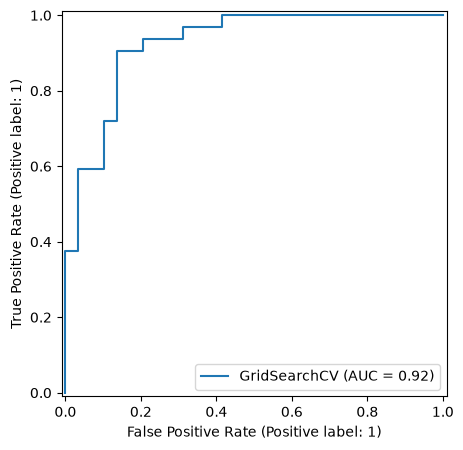

In [125]:
fig, ax = plt.subplots(figsize = (5, 5))
RocCurveDisplay.from_estimator(gs_log_reg,
                               X_test,
                               y_test,
                               ax = ax);

#### Confusion Matrix

[Text(0.5, 1.0, 'Confusion Matrix'),
 Text(0.5, 14.833333333333327, 'Predicted Label'),
 Text(33.33333333333333, 0.5, 'True Label')]

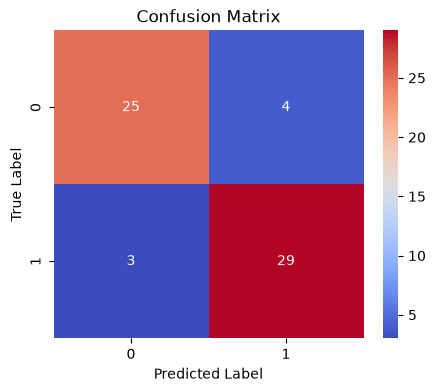

In [133]:
fig, ax = plt.subplots(figsize = (5, 4))
ax = sns.heatmap(confusion_matrix(y_test, y_pred),
                 annot = True,
                 cmap = "coolwarm")
ax.set(title = "Confusion Matrix",
       xlabel = "Predicted Label",
       ylabel = "True Label")

#### Classification Report

In [135]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



Our model has a recall score of 0.91 for Class 1 (has heart disease)
* This means our model correctly caught 91% of actual heart disease cases

> In our case, A `False Negative` (telling a sick patient they are actually healthy) is more costly that a `False Positive` (telling a healthy patient they might have Heart Disease)

#### Calculating Cross-Validated Accuracy, Precision, Recall, and F1-score 

In [136]:
gs_log_reg.best_params_

{'C': np.float64(0.22570197196339203), 'solver': 'liblinear'}

In [137]:
# Fitting the best params to a new LogisticRegression model
clf = LogisticRegression(C = 0.22570197196339203,
                         solver = "liblinear")

In [141]:
# Create function for cross-validated evaluation metrics
def cv_metrics(clf, X, y):
    scores = {}
    scores["Cross-Val Accuracy:"] = np.mean(cross_val_score(clf, X, y, cv = 5, scoring = "accuracy"))
    scores["Cross-Val Precision:"] = np.mean(cross_val_score(clf, X, y, cv = 5, scoring = "precision"))
    scores["Cross-Val Recall:"] = np.mean(cross_val_score(clf, X, y, cv = 5, scoring = "recall"))
    scores["Cross-Val F1-Score:"] = np.mean(cross_val_score(clf, X, y, cv = 5, scoring = "f1"))
    return scores

In [142]:
cross_val_scores = cv_metrics(clf, X, y)
cross_val_scores

{'Cross-Val Accuracy:': np.float64(0.8479781420765027),
 'Cross-Val Precision:': np.float64(0.8215873015873015),
 'Cross-Val Recall:': np.float64(0.9272727272727274),
 'Cross-Val F1-Score:': np.float64(0.8705403543192143)}

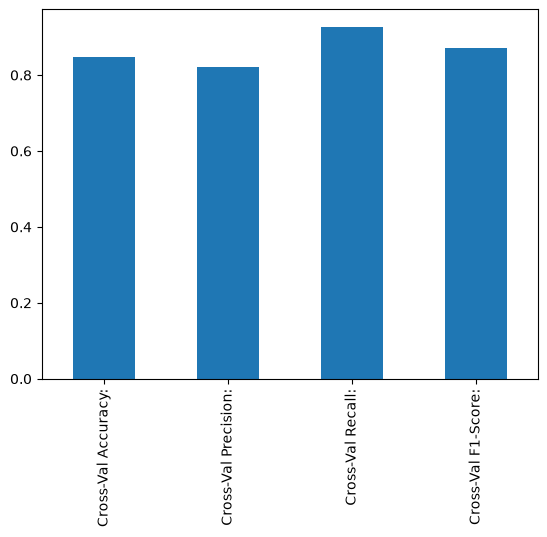

In [144]:
# Visualise our cross-validated metrics
cv_metrics_visualise = pd.DataFrame(cross_val_scores,
                                    index = [0])
cv_metrics_visualise.T.plot(kind = "bar",
                            legend = False);